>>> 데이터 로딩 중...
✅ 데이터셋 로드 완료!
   Train Shape: (27950, 60, 91)
   Test Shape:  (13976, 60, 91)
✅ 스케일러 로드 완료!
>>> 모델 생성 중...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 60, 128)        │       112,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 91)             │         5,915 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,963 (656.11 KB)

 Trainable params: 167,963 (656.11 KB)

 Non-trainable params: 0 (0.00 B)


>>> [1/2] 실수부(Real Part) 모델 학습 시작...
Epoch 1/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0260 - mae: 0.1220 - val_loss: 0.0138 - val_mae: 0.0922
Epoch 2/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0137 - mae: 0.0934 - val_loss: 0.0105 - val_mae: 0.0817
Epoch 3/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0112 - mae: 0.0845 - val_loss: 0.0091 - val_mae: 0.0761
Epoch 4/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0091 - mae: 0.0760 - val_loss: 0.0068 - val_mae: 0.0659
Epoch 5/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0085 - mae: 0.0732 - val_loss: 0.0065 - val_mae: 0.0642
Epoch 6/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0069 - mae: 0.0664 - val_loss: 0.0058 - val_mae: 0.0609
Epoch 7/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0063 - mae: 0.0630 - val_loss: 0.0062 - val_mae: 0.0617
Epoch 8/200
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0056 - mae: 0.0595 - val_loss: 0.0053 - val_mae: 0.0574
Epoch

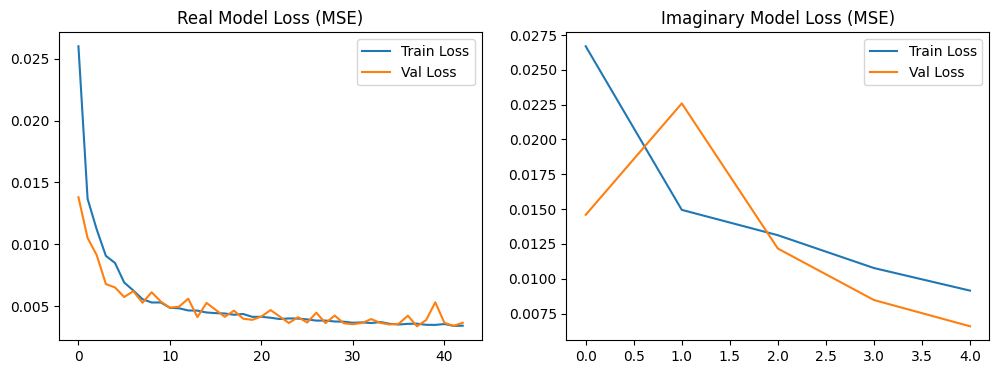


>>> 예측 수행 중 (Test Set)...
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

🔥 최종 성능 평가 (SNR 20.0dB 데이터)
NMSE: 0.59616
NMSE (dB): -2.25 dB


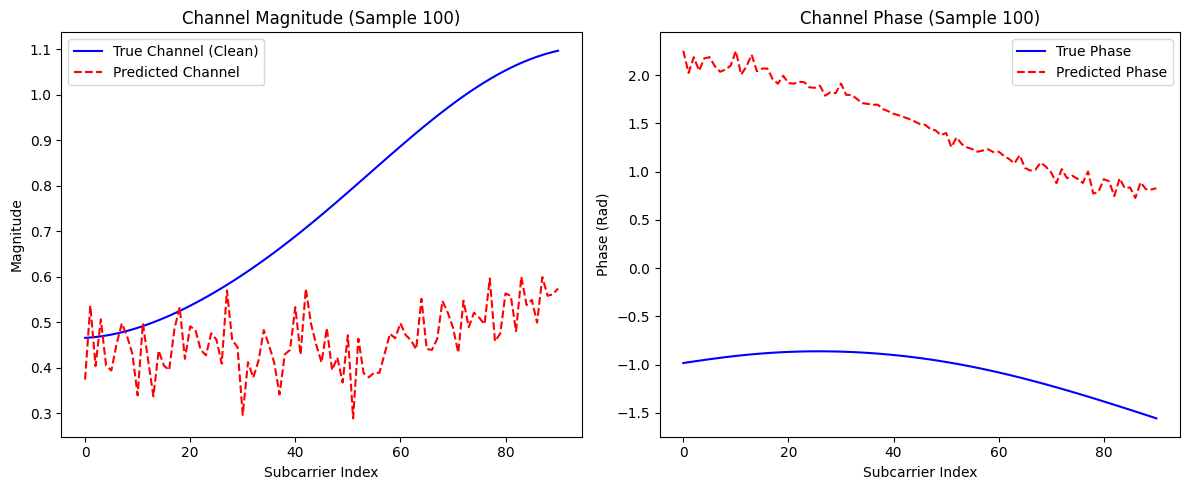

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import pickle

# --- 파라미터 ---
BATCH_SIZE = 64
EPOCHS = 200
LEARNING_RATE = 0.001
INPUT_SHAPE = (60, 91)

# ==========================================
# [추가된 부분] 저장된 데이터 불러오기
# ==========================================
print(">>> 데이터 로딩 중...")

# 1. 데이터 파일(.npz) 불러오기
try:
    data = np.load('processed_dataset.npz')
    
    # 변수들에 할당 (이름을 맞춰줘야 함)
    X_r_train = data['X_r_train']
    X_r_test  = data['X_r_test']
    Y_r_train = data['Y_r_train']
    Y_r_test  = data['Y_r_test']
    
    X_i_train = data['X_i_train']
    X_i_test  = data['X_i_test']
    Y_i_train = data['Y_i_train']
    Y_i_test  = data['Y_i_test']
    
    print("✅ 데이터셋 로드 완료!")
    print(f"   Train Shape: {X_r_train.shape}")
    print(f"   Test Shape:  {X_r_test.shape}")

except FileNotFoundError:
    print("❌ 'processed_dataset.npz' 파일이 없습니다. 전처리 코드를 실행하고 저장했는지 확인하세요.")
    raise # 멈춤

# 2. 스케일러 파일(.pkl) 불러오기
try:
    with open('scalers.pkl', 'rb') as f:
        scalers = pickle.load(f)
    print("✅ 스케일러 로드 완료!")
except FileNotFoundError:
    print("❌ 'scalers.pkl' 파일이 없습니다.")
    raise

# --- 2. 모델 정의 함수 (LSTM) ---
def create_lstm_model(input_shape):
    model = models.Sequential()
    
    # LSTM Layer 1
    # return_sequences=True: 다음 LSTM 층으로 시퀀스 전체를 전달
    model.add(layers.LSTM(128, input_shape=input_shape, return_sequences=True))
    model.add(layers.Dropout(0.2)) # 과적합 방지
    
    # LSTM Layer 2
    # return_sequences=False: 마지막 타임스텝의 결과만 출력 (Many-to-One)
    model.add(layers.LSTM(64, return_sequences=False))
    model.add(layers.Dropout(0.2))
    
    # Output Layer
    # 91개의 부반송파 값을 예측
    model.add(layers.Dense(91, activation='linear')) # Regression 문제이므로 Linear
    
    # Compile
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

# --- 3. 모델 생성 ---
print(">>> 모델 생성 중...")
model_real = create_lstm_model(INPUT_SHAPE)
model_imag = create_lstm_model(INPUT_SHAPE)

model_real.summary()

# --- 4. 학습 (Training) ---
# EarlyStopping: 성능이 더 이상 좋아지지 않으면 조기 종료
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n>>> [1/2] 실수부(Real Part) 모델 학습 시작...")
history_real = model_real.fit(
    X_r_train, Y_r_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1, # Train 데이터 중 10%를 검증용으로 사용
    callbacks=[early_stop],
    verbose=1
)

print("\n>>> [2/2] 허수부(Imaginary Part) 모델 학습 시작...")
history_imag = model_imag.fit(
    X_i_train, Y_i_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# --- 5. 학습 결과 시각화 (Loss Curve) ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_real.history['loss'], label='Train Loss')
plt.plot(history_real.history['val_loss'], label='Val Loss')
plt.title('Real Model Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imag.history['loss'], label='Train Loss')
plt.plot(history_imag.history['val_loss'], label='Val Loss')
plt.title('Imaginary Model Loss (MSE)')
plt.legend()
plt.show()

# --- 6. 예측 및 성능 평가 (NMSE) ---
print("\n>>> 예측 수행 중 (Test Set)...")
pred_r_norm = model_real.predict(X_r_test)
pred_i_norm = model_imag.predict(X_i_test)

# 역정규화 (Denormalization) 함수
def denorm(data, min_v, max_v):
    return data * (max_v - min_v) + min_v

# 원래 스케일로 복원
# scalers 딕셔너리는 2단계 코드에서 가져옴
pred_r = denorm(pred_r_norm, scalers['yr'][0], scalers['yr'][1])
pred_i = denorm(pred_i_norm, scalers['yi'][0], scalers['yi'][1])

target_r = denorm(Y_r_test, scalers['yr'][0], scalers['yr'][1])
target_i = denorm(Y_i_test, scalers['yi'][0], scalers['yi'][1])

# 복소수 채널 재구성
H_pred = pred_r + 1j * pred_i
H_true = target_r + 1j * target_i

# NMSE 계산 (논문 공식)
# NMSE = ||y - y_hat||^2 / ||y||^2
error_power = np.sum(np.abs(H_true - H_pred)**2)
signal_power = np.sum(np.abs(H_true)**2)

nmse = error_power / signal_power
nmse_db = 10 * np.log10(nmse)
SNR_DB = 20.0

print(f"\n========================================")
print(f"🔥 최종 성능 평가 (SNR {SNR_DB}dB 데이터)")
print(f"NMSE: {nmse:.5f}")
print(f"NMSE (dB): {nmse_db:.2f} dB")
print(f"========================================")

# --- 7. 최종 결과 시각화 (논문처럼 비교) ---
# 임의의 샘플 하나를 골라 비교
sample_idx = 100 # 아무거나
plt.figure(figsize=(12, 5))

# Magnitude 비교
plt.subplot(1, 2, 1)
plt.plot(np.abs(H_true[sample_idx]), 'b-', label='True Channel (Clean)')
plt.plot(np.abs(H_pred[sample_idx]), 'r--', label='Predicted Channel')
plt.title(f"Channel Magnitude (Sample {sample_idx})")
plt.xlabel("Subcarrier Index")
plt.ylabel("Magnitude")
plt.legend()

# Phase 비교
plt.subplot(1, 2, 2)
plt.plot(np.angle(H_true[sample_idx]), 'b-', label='True Phase')
plt.plot(np.angle(H_pred[sample_idx]), 'r--', label='Predicted Phase')
plt.title(f"Channel Phase (Sample {sample_idx})")
plt.xlabel("Subcarrier Index")
plt.ylabel("Phase (Rad)")
plt.legend()

plt.tight_layout()
plt.show()

>>> 데이터 로딩 중...
✅ 데이터셋 로드 완료!
   Train Shape: (27950, 60, 91)
   Test Shape:  (13976, 60, 91)
✅ 스케일러 로드 완료!
>>> 모델 생성 중...


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 60, 128)        │       112,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 91)             │         5,915 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,963 (656.11 KB)

 Trainable params: 167,963 (656.11 KB)

 Non-trainable params: 0 (0.00 B)


>>> [1/2] 실수부(Real Part) 모델 학습 시작...
Epoch 1/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.8049 - mae: 0.7173 - val_loss: 0.7988 - val_mae: 0.6935
Epoch 2/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.6635 - mae: 0.6498 - val_loss: 0.6891 - val_mae: 0.6569
Epoch 3/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5687 - mae: 0.5992 - val_loss: 0.6405 - val_mae: 0.6393
Epoch 4/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5064 - mae: 0.5656 - val_loss: 0.6599 - val_mae: 0.6406
Epoch 5/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.4468 - mae: 0.5294 - val_loss: 0.7056 - val_mae: 0.6713
Epoch 6/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.3862 - mae: 0.4929 - val_loss: 0.7193 - val_mae: 0.6753
Epoch 7/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.3350 - mae: 0.4577 - val_loss: 0.8578 - val_mae: 0.7431
Epoch 8/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2711 - mae: 0.4112 - val_loss: 0.7902 - val_mae: 0.7088

>>

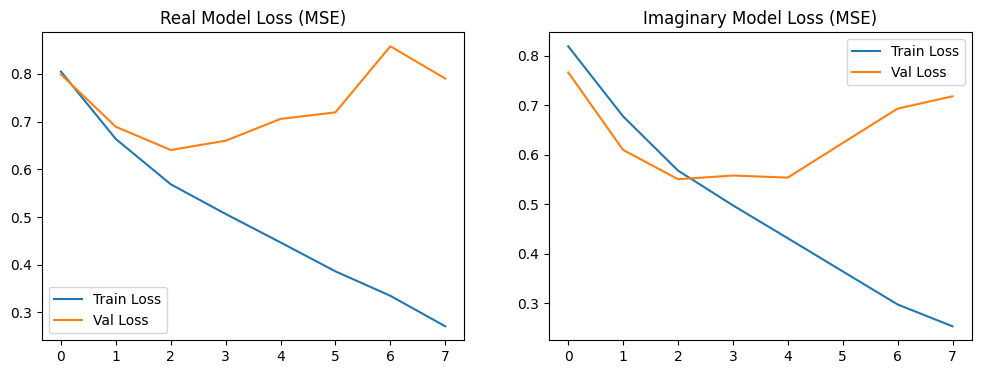


>>> 예측 수행 중 (Test Set)...
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
🔥 최종 성능 평가 (StandardScaler 적용)
NMSE (dB): -2.04 dB


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import pickle

# --- 파라미터 ---
BATCH_SIZE = 64
EPOCHS = 500
LEARNING_RATE = 0.001
INPUT_SHAPE = (60, 91)

# ==========================================
# [추가된 부분] 저장된 데이터 불러오기
# ==========================================
print(">>> 데이터 로딩 중...")

# 1. 데이터 파일(.npz) 불러오기
try:
    data = np.load('processed_dataset.npz')
    
    # 변수들에 할당 (이름을 맞춰줘야 함)
    X_r_train = data['X_r_train']
    X_r_test  = data['X_r_test']
    Y_r_train = data['Y_r_train']
    Y_r_test  = data['Y_r_test']
    
    X_i_train = data['X_i_train']
    X_i_test  = data['X_i_test']
    Y_i_train = data['Y_i_train']
    Y_i_test  = data['Y_i_test']
    
    print("✅ 데이터셋 로드 완료!")
    print(f"   Train Shape: {X_r_train.shape}")
    print(f"   Test Shape:  {X_r_test.shape}")

except FileNotFoundError:
    print("❌ 'processed_dataset.npz' 파일이 없습니다. 전처리 코드를 실행하고 저장했는지 확인하세요.")
    raise # 멈춤

# 2. 스케일러 파일(.pkl) 불러오기
try:
    with open('scalers.pkl', 'rb') as f:
        scalers = pickle.load(f)
    print("✅ 스케일러 로드 완료!")
except FileNotFoundError:
    print("❌ 'scalers.pkl' 파일이 없습니다.")
    raise

# --- 2. 모델 정의 함수 (LSTM) ---
def create_lstm_model(input_shape):
    model = models.Sequential()
    
    # LSTM Layer 1
    # return_sequences=True: 다음 LSTM 층으로 시퀀스 전체를 전달
    model.add(layers.LSTM(128, input_shape=input_shape, return_sequences=True))
    model.add(layers.Dropout(0.2)) # 과적합 방지
    
    # LSTM Layer 2
    # return_sequences=False: 마지막 타임스텝의 결과만 출력 (Many-to-One)
    model.add(layers.LSTM(64, return_sequences=False))
    model.add(layers.Dropout(0.2))
    
    # Output Layer
    # 91개의 부반송파 값을 예측
    model.add(layers.Dense(91, activation='linear')) # Regression 문제이므로 Linear
    
    # Compile
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

# --- 3. 모델 생성 ---
print(">>> 모델 생성 중...")
model_real = create_lstm_model(INPUT_SHAPE)
model_imag = create_lstm_model(INPUT_SHAPE)

model_real.summary()

# --- 4. 학습 (Training) ---
# EarlyStopping: 성능이 더 이상 좋아지지 않으면 조기 종료
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n>>> [1/2] 실수부(Real Part) 모델 학습 시작...")
history_real = model_real.fit(
    X_r_train, Y_r_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1, # Train 데이터 중 10%를 검증용으로 사용
    callbacks=[early_stop],
    verbose=1
)

print("\n>>> [2/2] 허수부(Imaginary Part) 모델 학습 시작...")
history_imag = model_imag.fit(
    X_i_train, Y_i_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# --- 5. 학습 결과 시각화 (Loss Curve) ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_real.history['loss'], label='Train Loss')
plt.plot(history_real.history['val_loss'], label='Val Loss')
plt.title('Real Model Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imag.history['loss'], label='Train Loss')
plt.plot(history_imag.history['val_loss'], label='Val Loss')
plt.title('Imaginary Model Loss (MSE)')
plt.legend()
plt.show()

# --- 6. 예측 및 성능 평가 (NMSE) ---
print("\n>>> 예측 수행 중 (Test Set)...")
pred_r_scaled = model_real.predict(X_r_test)
pred_i_scaled = model_imag.predict(X_i_test)

# StandardScaler 역변환 (inverse_transform)
# scaler_yr는 (91,) 크기의 평균/분산을 가지고 있음
scaler_yr = scalers['yr']
scaler_yi = scalers['yi']

pred_r = scaler_yr.inverse_transform(pred_r_scaled)
pred_i = scaler_yi.inverse_transform(pred_i_scaled)

# 정답 데이터도 원래 스케일로 복원
target_r = scaler_yr.inverse_transform(Y_r_test)
target_i = scaler_yi.inverse_transform(Y_i_test)

# 복소수 결합
H_pred = pred_r + 1j * pred_i
H_true = target_r + 1j * target_i

# NMSE 계산
error_power = np.sum(np.abs(H_true - H_pred)**2)
signal_power = np.sum(np.abs(H_true)**2)
nmse_db = 10 * np.log10(error_power / signal_power)

print(f"🔥 최종 성능 평가 (StandardScaler 적용)")
print(f"NMSE (dB): {nmse_db:.2f} dB")



✅ Raw 데이터 로드 성공: (42000, 624)

>>> 전처리 시작 (Horizon: 1, SNR: 20.0dB)...
   - 윈도우 생성 완료. X: (41939, 60, 91), Y: (41939, 91)

>>> [데이터 Shape 검증]
X_r_train: (33551, 60, 91)
Y_r_train: (33551, 91)

>>> [1/2] 실수부(Real) 학습 시작...


I0000 00:00:1766471213.137710 3719940 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22323 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:81:00.0, compute capability: 8.6
I0000 00:00:1766471213.139087 3719940 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22323 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:c1:00.0, compute capability: 8.6
/home/lab602/miniconda3/envs/sionna_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1766471216.557637 3720448 cuda_dnn.cc:529] Loaded cuDNN version 90300


420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.3708 - val_loss: 0.1196 - learning_rate: 5.0000e-04
Epoch 2/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.1097 - val_loss: 0.0621 - learning_rate: 5.0000e-04
Epoch 3/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0763 - val_loss: 0.0420 - learning_rate: 5.0000e-04
Epoch 4/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0608 - val_loss: 0.0342 - learning_rate: 5.0000e-04
Epoch 5/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0526 - val_loss: 0.0269 - learning_rate: 5.0000e-04
Epoch 6/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0474 - val_loss: 0.0242 - learning_rate: 5.0000e-04
Epoch 7/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0439 - val_loss: 0.0207 - learning_rate: 5.0000e-04
Epoch 8/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0415 - val_loss: 0.0159 - learning_rate: 5.0000e-04
Epoch 9/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0394 - val_loss: 0.0156 - lea

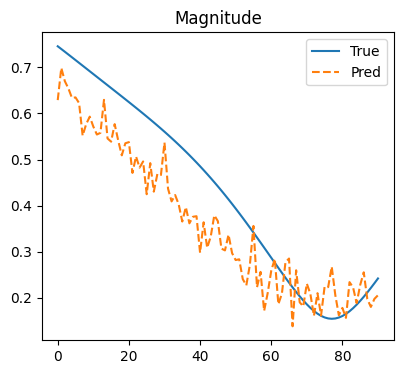

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ==========================================
# 1. 데이터 로드 및 초기화
# ==========================================
try:
    raw_data = np.load('raw_channel_data.npy')
    print(f"✅ Raw 데이터 로드 성공: {raw_data.shape}")
except FileNotFoundError:
    print("❌ 'raw_channel_data.npy' 파일이 없습니다.")
    raise

# 파라미터 (1 Step 예측 디버깅)
PREDICTION_HORIZON = 1 
WINDOW_SIZE = 60
SUB_CARRIERS = 91
CENTER_IDX = 624 // 2
SNR_DB = 20.0

# ==========================================
# 2. 전처리 함수 (오류 수정됨)
# ==========================================
def preprocess_robust(data, snr_db):
    print(f"\n>>> 전처리 시작 (Horizon: {PREDICTION_HORIZON}, SNR: {snr_db}dB)...")
    
    # 1. Crop
    start = CENTER_IDX - (SUB_CARRIERS // 2)
    end = CENTER_IDX + (SUB_CARRIERS // 2) + 1
    data_cropped = data[:, start:end]
    
    # 2. Noise Injection
    sig_power = np.mean(np.abs(data_cropped)**2)
    noise_power = sig_power / (10**(snr_db/10))
    noise = (np.random.randn(*data_cropped.shape) + 1j * np.random.randn(*data_cropped.shape)) * np.sqrt(noise_power/2)
    
    noisy_input = data_cropped + noise
    clean_target = data_cropped

    # 3. Windowing
    num_samples = len(data_cropped) - WINDOW_SIZE - PREDICTION_HORIZON
    X_list, Y_list = [], []
    
    for i in range(num_samples):
        X_list.append(noisy_input[i : i+WINDOW_SIZE])
        Y_list.append(clean_target[i + WINDOW_SIZE + PREDICTION_HORIZON - 1])
        
    X = np.array(X_list)
    Y = np.array(Y_list)
    
    print(f"   - 윈도우 생성 완료. X: {X.shape}, Y: {Y.shape}")
    
    # 4. Train/Test Split
    split_idx = int(len(X) * 0.8)
    
    X_train_c = X[:split_idx]
    X_test_c  = X[split_idx:]
    Y_train_c = Y[:split_idx]
    Y_test_c  = Y[split_idx:]
    
    # 5. Scaling (실수/허수 분리 및 정규화)
    def scale_and_split(X_tr, X_te, Y_tr, Y_te):
        N_tr, T, F = X_tr.shape
        N_te = X_te.shape[0]
        
        # Flatten
        xr_tr = np.real(X_tr).reshape(N_tr, -1)
        xr_te = np.real(X_te).reshape(N_te, -1)
        xi_tr = np.imag(X_tr).reshape(N_tr, -1)
        xi_te = np.imag(X_te).reshape(N_te, -1)
        
        yr_tr = np.real(Y_tr)
        yr_te = np.real(Y_te)
        yi_tr = np.imag(Y_tr)
        yi_te = np.imag(Y_te)
        
        # Scalers
        s_xr, s_xi = StandardScaler(), StandardScaler()
        s_yr, s_yi = StandardScaler(), StandardScaler()
        
        # Fit & Transform
        xr_tr = s_xr.fit_transform(xr_tr)
        xr_te = s_xr.transform(xr_te)
        xi_tr = s_xi.fit_transform(xi_tr)
        xi_te = s_xi.transform(xi_te)
        
        # [수정된 부분] 변수에 할당을 확실하게!
        Y_r_train = s_yr.fit_transform(yr_tr)
        Y_r_test  = s_yr.transform(yr_te)
        Y_i_train = s_yi.fit_transform(yi_tr)
        Y_i_test  = s_yi.transform(yi_te)
        
        # Reshape X back to 3D
        X_r_train = xr_tr.reshape(N_tr, T, F)
        X_r_test  = xr_te.reshape(N_te, T, F)
        X_i_train = xi_tr.reshape(N_tr, T, F)
        X_i_test  = xi_te.reshape(N_te, T, F)
        
        scalers = {'yr': s_yr, 'yi': s_yi}
        
        return (X_r_train, X_r_test, Y_r_train, Y_r_test), \
               (X_i_train, X_i_test, Y_i_train, Y_i_test), scalers

    return scale_and_split(X_train_c, X_test_c, Y_train_c, Y_test_c)

# ==========================================
# 3. 데이터 준비
# ==========================================
(real_sets, imag_sets, scalers) = preprocess_robust(raw_data, SNR_DB)

X_r_train, X_r_test, Y_r_train, Y_r_test = real_sets
X_i_train, X_i_test, Y_i_train, Y_i_test = imag_sets

print("\n>>> [데이터 Shape 검증]")
print(f"X_r_train: {X_r_train.shape}")
print(f"Y_r_train: {Y_r_train.shape}")

# ==========================================
# 4. 모델 정의 및 학습
# ==========================================
def create_robust_lstm(input_shape):
    model = models.Sequential()
    reg = regularizers.l2(0.001)
    
    model.add(layers.LSTM(64, input_shape=input_shape, return_sequences=True, kernel_regularizer=reg))
    model.add(layers.Dropout(0.3))
    model.add(layers.LSTM(32, return_sequences=False, kernel_regularizer=reg))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(91, activation='linear'))
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse')
    return model

# 콜백 설정
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\n>>> [1/2] 실수부(Real) 학습 시작...")
model_real = create_robust_lstm((WINDOW_SIZE, SUB_CARRIERS))
hist_r = model_real.fit(X_r_train, Y_r_train, epochs=50, batch_size=64, 
                        validation_split=0.2, callbacks=[reduce_lr, early_stop], verbose=1)

print("\n>>> [2/2] 허수부(Imag) 학습 시작...")
model_imag = create_robust_lstm((WINDOW_SIZE, SUB_CARRIERS))
hist_i = model_imag.fit(X_i_train, Y_i_train, epochs=50, batch_size=64, 
                        validation_split=0.2, callbacks=[reduce_lr, early_stop], verbose=0)

# ==========================================
# 5. 최종 평가
# ==========================================
print("\n>>> 평가 중...")
pred_r_s = model_real.predict(X_r_test)
pred_i_s = model_imag.predict(X_i_test)

# 역변환
pred_r = scalers['yr'].inverse_transform(pred_r_s)
pred_i = scalers['yi'].inverse_transform(pred_i_s)
target_r = scalers['yr'].inverse_transform(Y_r_test)
target_i = scalers['yi'].inverse_transform(Y_i_test)

H_pred = pred_r + 1j * pred_i
H_true = target_r + 1j * target_i

nmse_db = 10 * np.log10(np.sum(np.abs(H_true - H_pred)**2) / np.sum(np.abs(H_true)**2))

print(f"\n========================================")
print(f"🔥 디버깅 결과 (Horizon={PREDICTION_HORIZON} step)")
print(f"NMSE (dB): {nmse_db:.2f} dB")
print(f"========================================")

# 시각화
sample_idx = 0
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(np.abs(H_true[sample_idx]), label='True')
plt.plot(np.abs(H_pred[sample_idx]), '--', label='Pred')
plt.title('Magnitude')
plt.legend()
plt.show()

>>> [High-Spec] 14 Step 데이터 생성 중...

>>> 전처리 시작 (Horizon: 14, SNR: 20.0dB)...
   - 윈도우 생성 완료. X: (41926, 60, 91), Y: (41926, 91)

>>> [1/2] 실수부(Real) Balanced 모델 학습...
Epoch 1/70
420/420 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 1.7616 - val_loss: 1.2916 - learning_rate: 5.0000e-04
Epoch 2/70
418/420 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0285
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.9528 - val_loss: 1.0497 - learning_rate: 5.0000e-04
Epoch 3/70
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.7329 - val_loss: 0.8328 - learning_rate: 2.5000e-04
Epoch 4/70
417/420 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6143
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.5877 - val_loss: 0.6430 - learning_rate: 2.5000e-04
Epoch 5/70
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.4838 - val_loss: 0.5239 - learning_rate: 1.

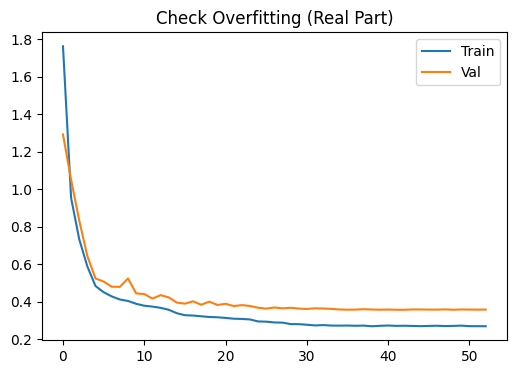

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ==========================================
# 1. 데이터 로드 및 전처리 (14 Step 설정)
# ==========================================
# (이전에 정의한 preprocess_robust 함수가 메모리에 있다고 가정합니다)
# 없다면 2번 파일을 다시 실행해주세요.

PREDICTION_HORIZON = 14  # 목표: 14 Step (14ms)
SNR_DB = 20.0

print(f">>> [High-Spec] 14 Step 데이터 생성 중...")
(real_sets, imag_sets, scalers) = preprocess_robust(raw_data, SNR_DB)

X_r_train, X_r_test, Y_r_train, Y_r_test = real_sets
X_i_train, X_i_test, Y_i_train, Y_i_test = imag_sets

# ==========================================
# 2. [수정됨] 고성능 LSTM 모델 (High Capacity)
# ==========================================
def create_balanced_lstm(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # [Layer 1] LSTM + L2 규제
    x = layers.LSTM(128, return_sequences=True, 
                    kernel_regularizer=regularizers.l2(0.005))(inputs)
    x = layers.BatchNormalization()(x) # 배치 정규화 추가
    x = layers.Dropout(0.4)(x)         # 드롭아웃 대폭 증가 (40%를 버림)
    
    # [Layer 2] LSTM
    x = layers.LSTM(64, return_sequences=False,
                    kernel_regularizer=regularizers.l2(0.005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    # [Layer 3] Dense (Interpretation)
    x = layers.Dense(64, activation='relu', 
                     kernel_regularizer=regularizers.l2(0.005))(x)
    
    # [Output]
    outputs = layers.Dense(91, activation='linear')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    # 학습률을 조금 낮춰서 천천히 진득하게 학습
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse')
    return model

# --- 실행 코드 (모델 생성 부분만 교체) ---

print("\n>>> [1/2] 실수부(Real) Balanced 모델 학습...")
model_real = create_balanced_lstm((WINDOW_SIZE, SUB_CARRIERS))
hist_r = model_real.fit(X_r_train, Y_r_train, 
                        epochs=70,  # Epoch 적당히
                        batch_size=64, 
                        validation_split=0.2, 
                        callbacks=[reduce_lr, early_stop], 
                        verbose=1)

print("\n>>> [2/2] 허수부(Imag) Balanced 모델 학습...")
model_imag = create_balanced_lstm((WINDOW_SIZE, SUB_CARRIERS))
hist_i = model_imag.fit(X_i_train, Y_i_train, 
                        epochs=70, 
                        batch_size=64, 
                        validation_split=0.2, 
                        callbacks=[reduce_lr, early_stop], 
                        verbose=0)

# --- 평가 ---
print("\n>>> 평가 중...")
pred_r = scalers['yr'].inverse_transform(model_real.predict(X_r_test))
pred_i = scalers['yi'].inverse_transform(model_imag.predict(X_i_test))

target_r = scalers['yr'].inverse_transform(Y_r_test)
target_i = scalers['yi'].inverse_transform(Y_i_test)

H_pred = pred_r + 1j * pred_i
H_true = target_r + 1j * target_i

nmse_db = 10 * np.log10(np.sum(np.abs(H_true - H_pred)**2) / np.sum(np.abs(H_true)**2))

print(f"\n========================================")
print(f"🔥 14 Step Balanced 튜닝 결과")
print(f"NMSE (dB): {nmse_db:.2f} dB")
print(f"========================================")

# 과적합 여부 확인용 그래프
plt.figure(figsize=(6, 4))
plt.plot(hist_r.history['loss'], label='Train')
plt.plot(hist_r.history['val_loss'], label='Val')
plt.title('Check Overfitting (Real Part)')
plt.legend()
plt.show()